In [1]:
from grid_world import GridWorldEnv
from dynamic_programming import value_iteration
from mdp import extract_mdp
import numpy as np
import matplotlib.pyplot as plt

# Create Grid World Environment

In [2]:
# Create new environment with (row, col) coordinates
env = GridWorldEnv(rows=5, cols=5, obstacles={(1, 1), (2, 2), (3, 1)})

***Markov Decision Process***
we want to get the states, actios and transition probabilites

In [3]:
states, actions, transition_probabilites = extract_mdp(env)

## Algorithms

## 1. Dynamic Programming using Value iteration

✅ Converged in 89 iterations, time = 0.012s


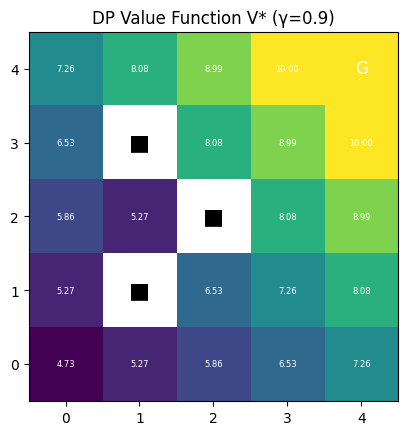

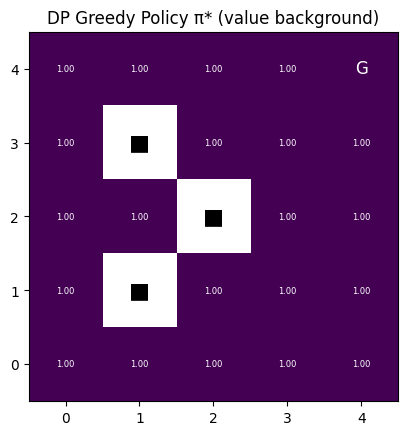

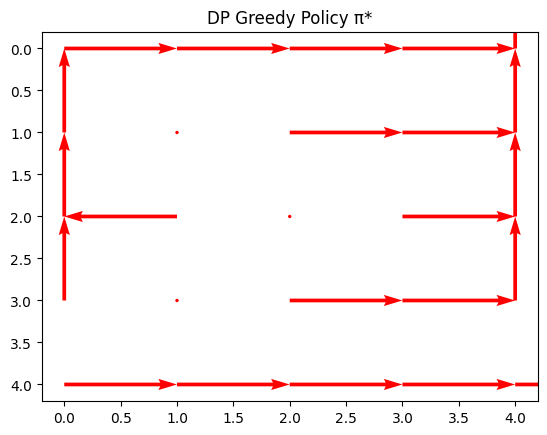

In [ ]:
# ┌─── Cell: Dynamic Programming (Value Iteration) ───────────────────────────────

import time
from utils import RLConfig, plot_value_function, plot_policy_arrows_from_q

# 2) Configure & run Value Iteration
config = RLConfig(gamma=0.9)  # use γ=0.9 as per assignment
start = time.time()
V_opt, pi_opt, iterations = value_iteration(
    states, actions, transition_probabilites, gamma=config.gamma, theta=1e-4
)
elapsed = time.time() - start
print(f"✅ Converged in {iterations} iterations, time = {elapsed:.3f}s")

# 3) Plot the optimal value function
plot_value_function(V_opt, env, title=f"DP Value Function V* (γ={config.gamma})")

# 4) Plot the greedy policy π* using our arrow‐plotting utility
#    We turn π into a “dummy Q” so we can reuse plot_policy_arrows_from_q:
Q_dummy = {(s, a): 1.0 if a == pi_opt[s] else 0.0 for s in states for a in actions}
plot_policy_arrows_from_q(Q_dummy, env, title="DP Greedy Policy π*")
# └───────────────────────────────────────────────────────────────────────────────

## 2. Monte Carlo Methods - using random policy

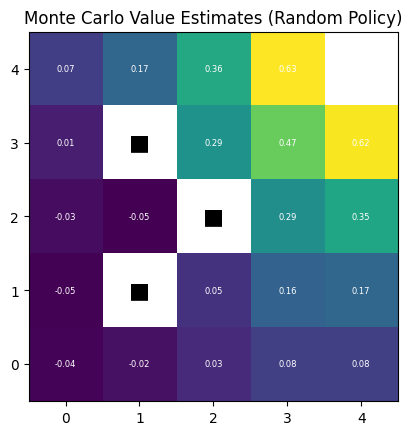

In [5]:
# ┌─── Cell: Monte Carlo Prediction (Random Policy) ───────────────────────────────
from monte_carlo import monte_carlo_prediction, random_policy_factory

# 2) Monte Carlo Prediction Config
config = RLConfig(gamma=0.9, episodes=1000, max_steps=100)

# 3) Use a random policy generator
random_policy = random_policy_factory(env.action_space)

# 4) Run Monte Carlo Prediction
V_mc = monte_carlo_prediction(
    env=env, policy=random_policy, num_episodes=config.episodes, gamma=config.gamma
)

# 5) Plot the learned value function
plot_value_function(V_mc, env, title="Monte Carlo Value Estimates (Random Policy)")
# └───────────────────────────────────────────────────────────────────────────────